In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
%matplotlib inline
from operator import itemgetter
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("ev_charging_patterns.csv")

In [4]:
df.head(5)

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [5]:
df.shape

(1320, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User ID                                   1320 non-null   object 
 1   Vehicle Model                             1320 non-null   object 
 2   Battery Capacity (kWh)                    1320 non-null   float64
 3   Charging Station ID                       1320 non-null   object 
 4   Charging Station Location                 1320 non-null   object 
 5   Charging Start Time                       1320 non-null   object 
 6   Charging End Time                         1320 non-null   object 
 7   Energy Consumed (kWh)                     1254 non-null   float64
 8   Charging Duration (hours)                 1320 non-null   float64
 9   Charging Rate (kW)                        1254 non-null   float64
 10  Charging Cost (USD)                 

In [7]:
df.isnull().sum()

User ID                                      0
Vehicle Model                                0
Battery Capacity (kWh)                       0
Charging Station ID                          0
Charging Station Location                    0
Charging Start Time                          0
Charging End Time                            0
Energy Consumed (kWh)                       66
Charging Duration (hours)                    0
Charging Rate (kW)                          66
Charging Cost (USD)                          0
Time of Day                                  0
Day of Week                                  0
State of Charge (Start %)                    0
State of Charge (End %)                      0
Distance Driven (since last charge) (km)    66
Temperature (°C)                             0
Vehicle Age (years)                          0
Charger Type                                 0
User Type                                    0
dtype: int64

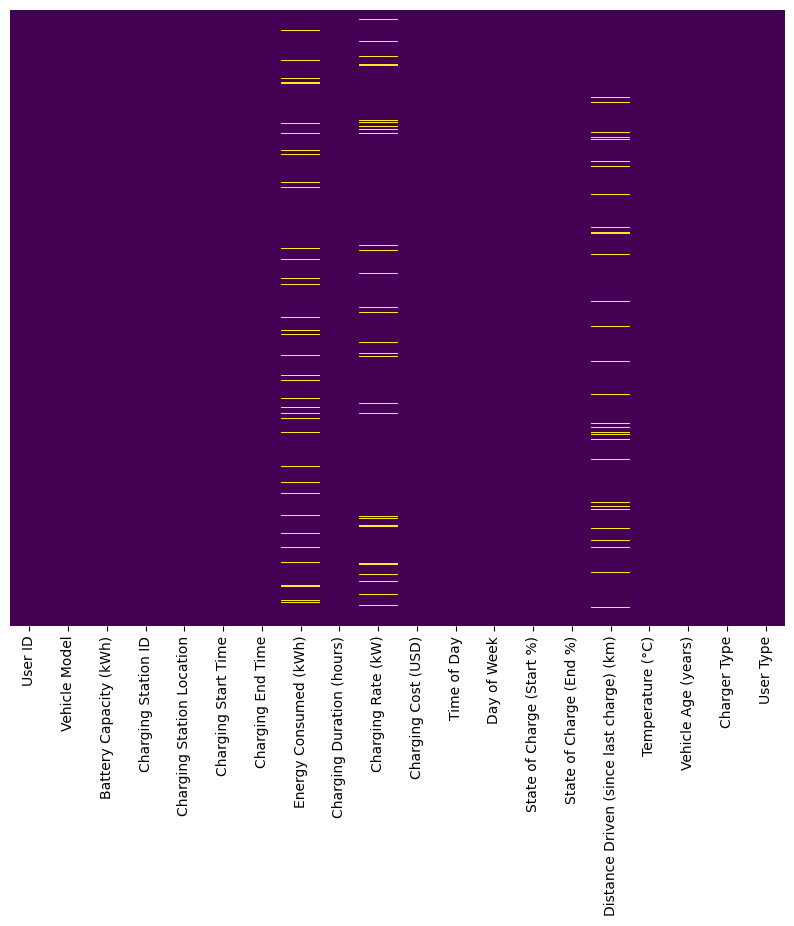

In [8]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
plt.show()

In [9]:
df.isnull().sum().sort_values(ascending=False)

Distance Driven (since last charge) (km)    66
Energy Consumed (kWh)                       66
Charging Rate (kW)                          66
User ID                                      0
Time of Day                                  0
Charger Type                                 0
Vehicle Age (years)                          0
Temperature (°C)                             0
State of Charge (End %)                      0
State of Charge (Start %)                    0
Day of Week                                  0
Charging Cost (USD)                          0
Vehicle Model                                0
Charging Duration (hours)                    0
Charging End Time                            0
Charging Start Time                          0
Charging Station Location                    0
Charging Station ID                          0
Battery Capacity (kWh)                       0
User Type                                    0
dtype: int64

df.duplicated().sum()

In [10]:
data_num = df.select_dtypes(include=[np.number])
num_cols_lst = data_num.columns
num_cols_lst.tolist()

['Battery Capacity (kWh)',
 'Energy Consumed (kWh)',
 'Charging Duration (hours)',
 'Charging Rate (kW)',
 'Charging Cost (USD)',
 'State of Charge (Start %)',
 'State of Charge (End %)',
 'Distance Driven (since last charge) (km)',
 'Temperature (°C)',
 'Vehicle Age (years)']

In [11]:
cat_data = df.select_dtypes(include=['object'])
cat_cols_lst = cat_data.columns
cat_cols_lst.tolist()

['User ID',
 'Vehicle Model',
 'Charging Station ID',
 'Charging Station Location',
 'Charging Start Time',
 'Charging End Time',
 'Time of Day',
 'Day of Week',
 'Charger Type',
 'User Type']

In [12]:
df[cat_cols_lst] = df[cat_cols_lst].apply(lambda x: x.fillna(x.value_counts().index[0]))

In [13]:
df.dropna (inplace=True)

In [14]:
df.isnull().sum()

User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Rate (kW)                          0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
dtype: int64

In [15]:
df.describe()

,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years)
count,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000
mean,74.427818,42.915668,2.303177,26.014166,22.488351,49.230036,75.012917,153.663101,15.305780,3.604227
std,20.828350,22.201286,1.065878,14.010292,10.792504,24.170435,16.920463,85.549751,14.751266,2.324090
min,1.536540,0.045772,0.095314,1.472549,0.307085,2.325959,7.604224,1.899538,-10.724770,0.000000
25%,62.000000,24.248936,1.425281,13.949809,13.133925,27.661992,62.264460,80.954993,3.009498,2.000000
50%,75.000000,42.865611,2.312675,25.838488,21.828088,48.947886,75.100944,152.257515,14.641853,4.000000
75%,85.000000,61.544055,3.145998,37.508677,31.675804,69.783816,88.245070,225.469628,27.824244,6.000000
max,193.003074,152.238758,7.635145,97.342255,69.407743,125.087227,177.708666,398.364775,73.169588,11.688592


### BIVARIATE GRAPH ###

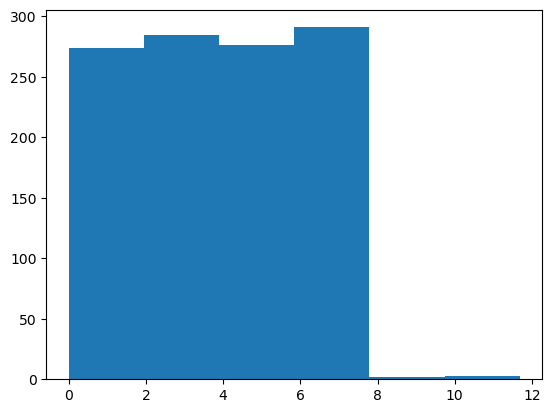

In [16]:
plt.hist(df['Vehicle Age (years)'], bins = 6)
plt.show()

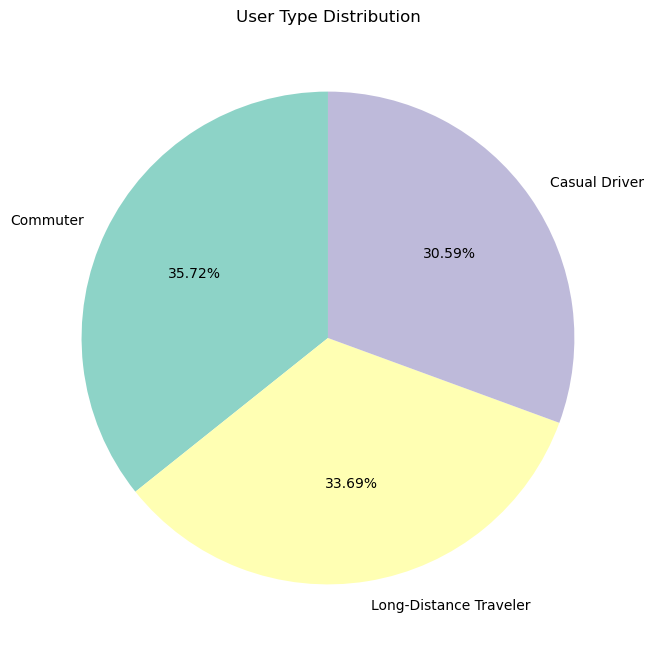

In [17]:
plt.figure(figsize=(8, 8))
df['User Type'].value_counts().plot(kind='pie', autopct='%.2f%%', colors=sns.color_palette('Set3'), startangle=90)
plt.title('User Type Distribution')
plt.ylabel('') 
plt.show()

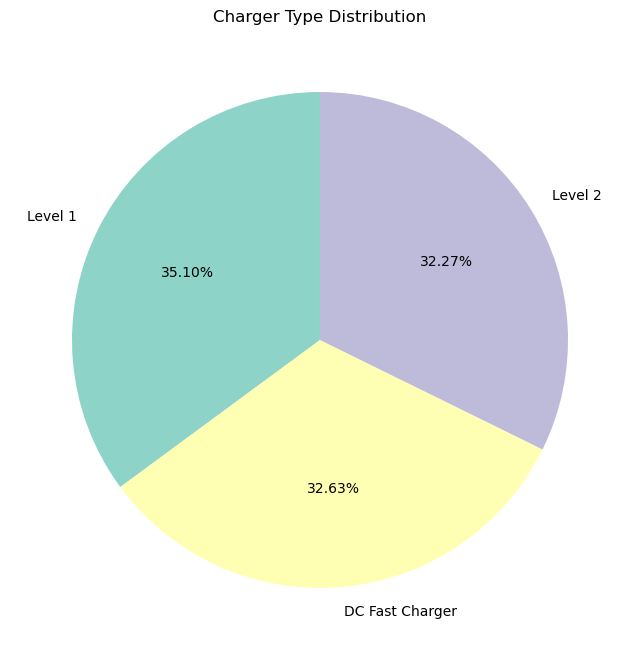

In [18]:
plt.figure(figsize=(8, 68))
df['Charger Type'].value_counts().plot(kind='pie', autopct='%.2f%%', colors=sns.color_palette('Set3'), startangle=90)
plt.title('Charger Type Distribution')
plt.ylabel('') 
plt.show()

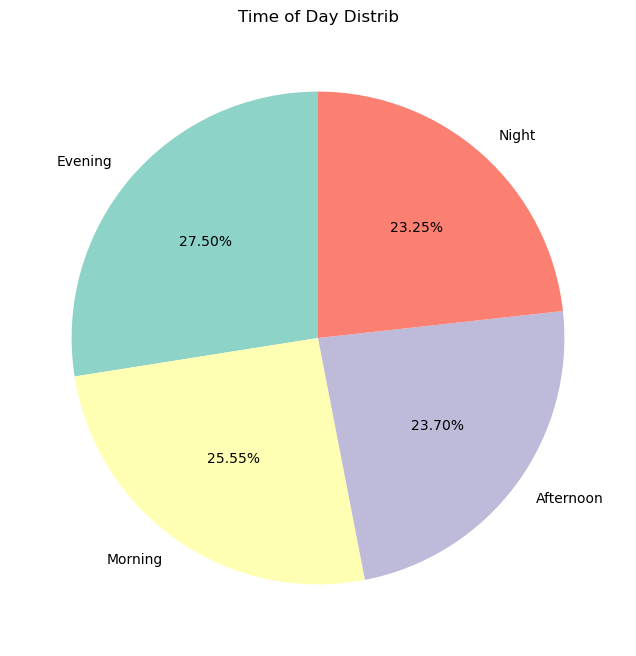

In [19]:
plt.figure(figsize=(8,8))
df['Time of Day'].value_counts().plot(kind='pie', autopct='%.2f%%', colors=sns.color_palette('Set3'), startangle=90)
plt.title('Time of Day Distrib')
plt.ylabel('') 
plt.show()

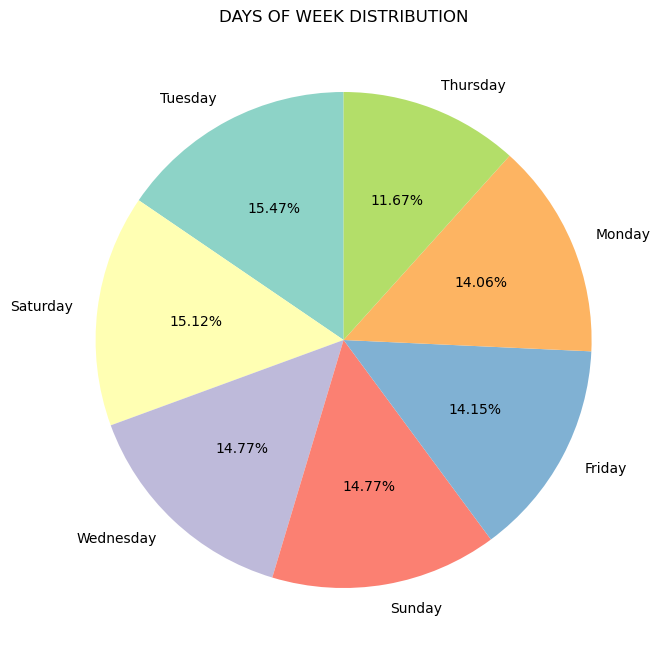

In [20]:
plt.figure(figsize=(8, 68))
df['Day of Week'].value_counts().plot(kind='pie', autopct='%.2f%%', colors=sns.color_palette('Set3'), startangle=90)
plt.title('DAYS OF WEEK DISTRIBUTION')
plt.ylabel('') 
plt.show()

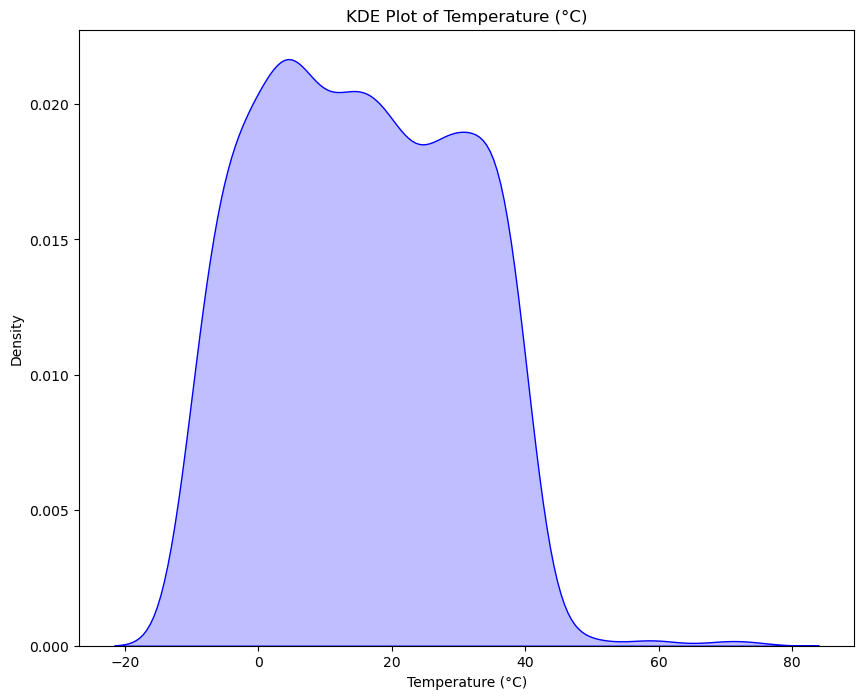

In [21]:
plt.figure(figsize=(10, 8))
sns.kdeplot(df['Temperature (°C)'], color='blue', shade=True)
plt.title('KDE Plot of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.show()

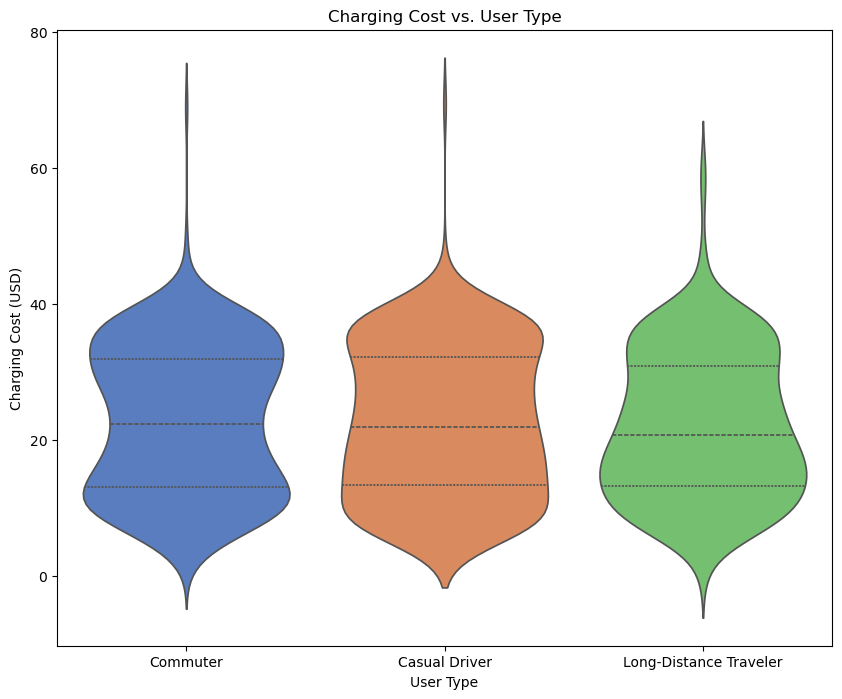

In [22]:
plt.figure(figsize=(10, 8))
sns.violinplot(x='User Type', y='Charging Cost (USD)', data=df, palette='muted', inner='quartile')
plt.title('Charging Cost vs. User Type')
plt.xlabel('User Type')
plt.ylabel('Charging Cost (USD)')
plt.show()

### MULTIVARIATE GRAPH ###

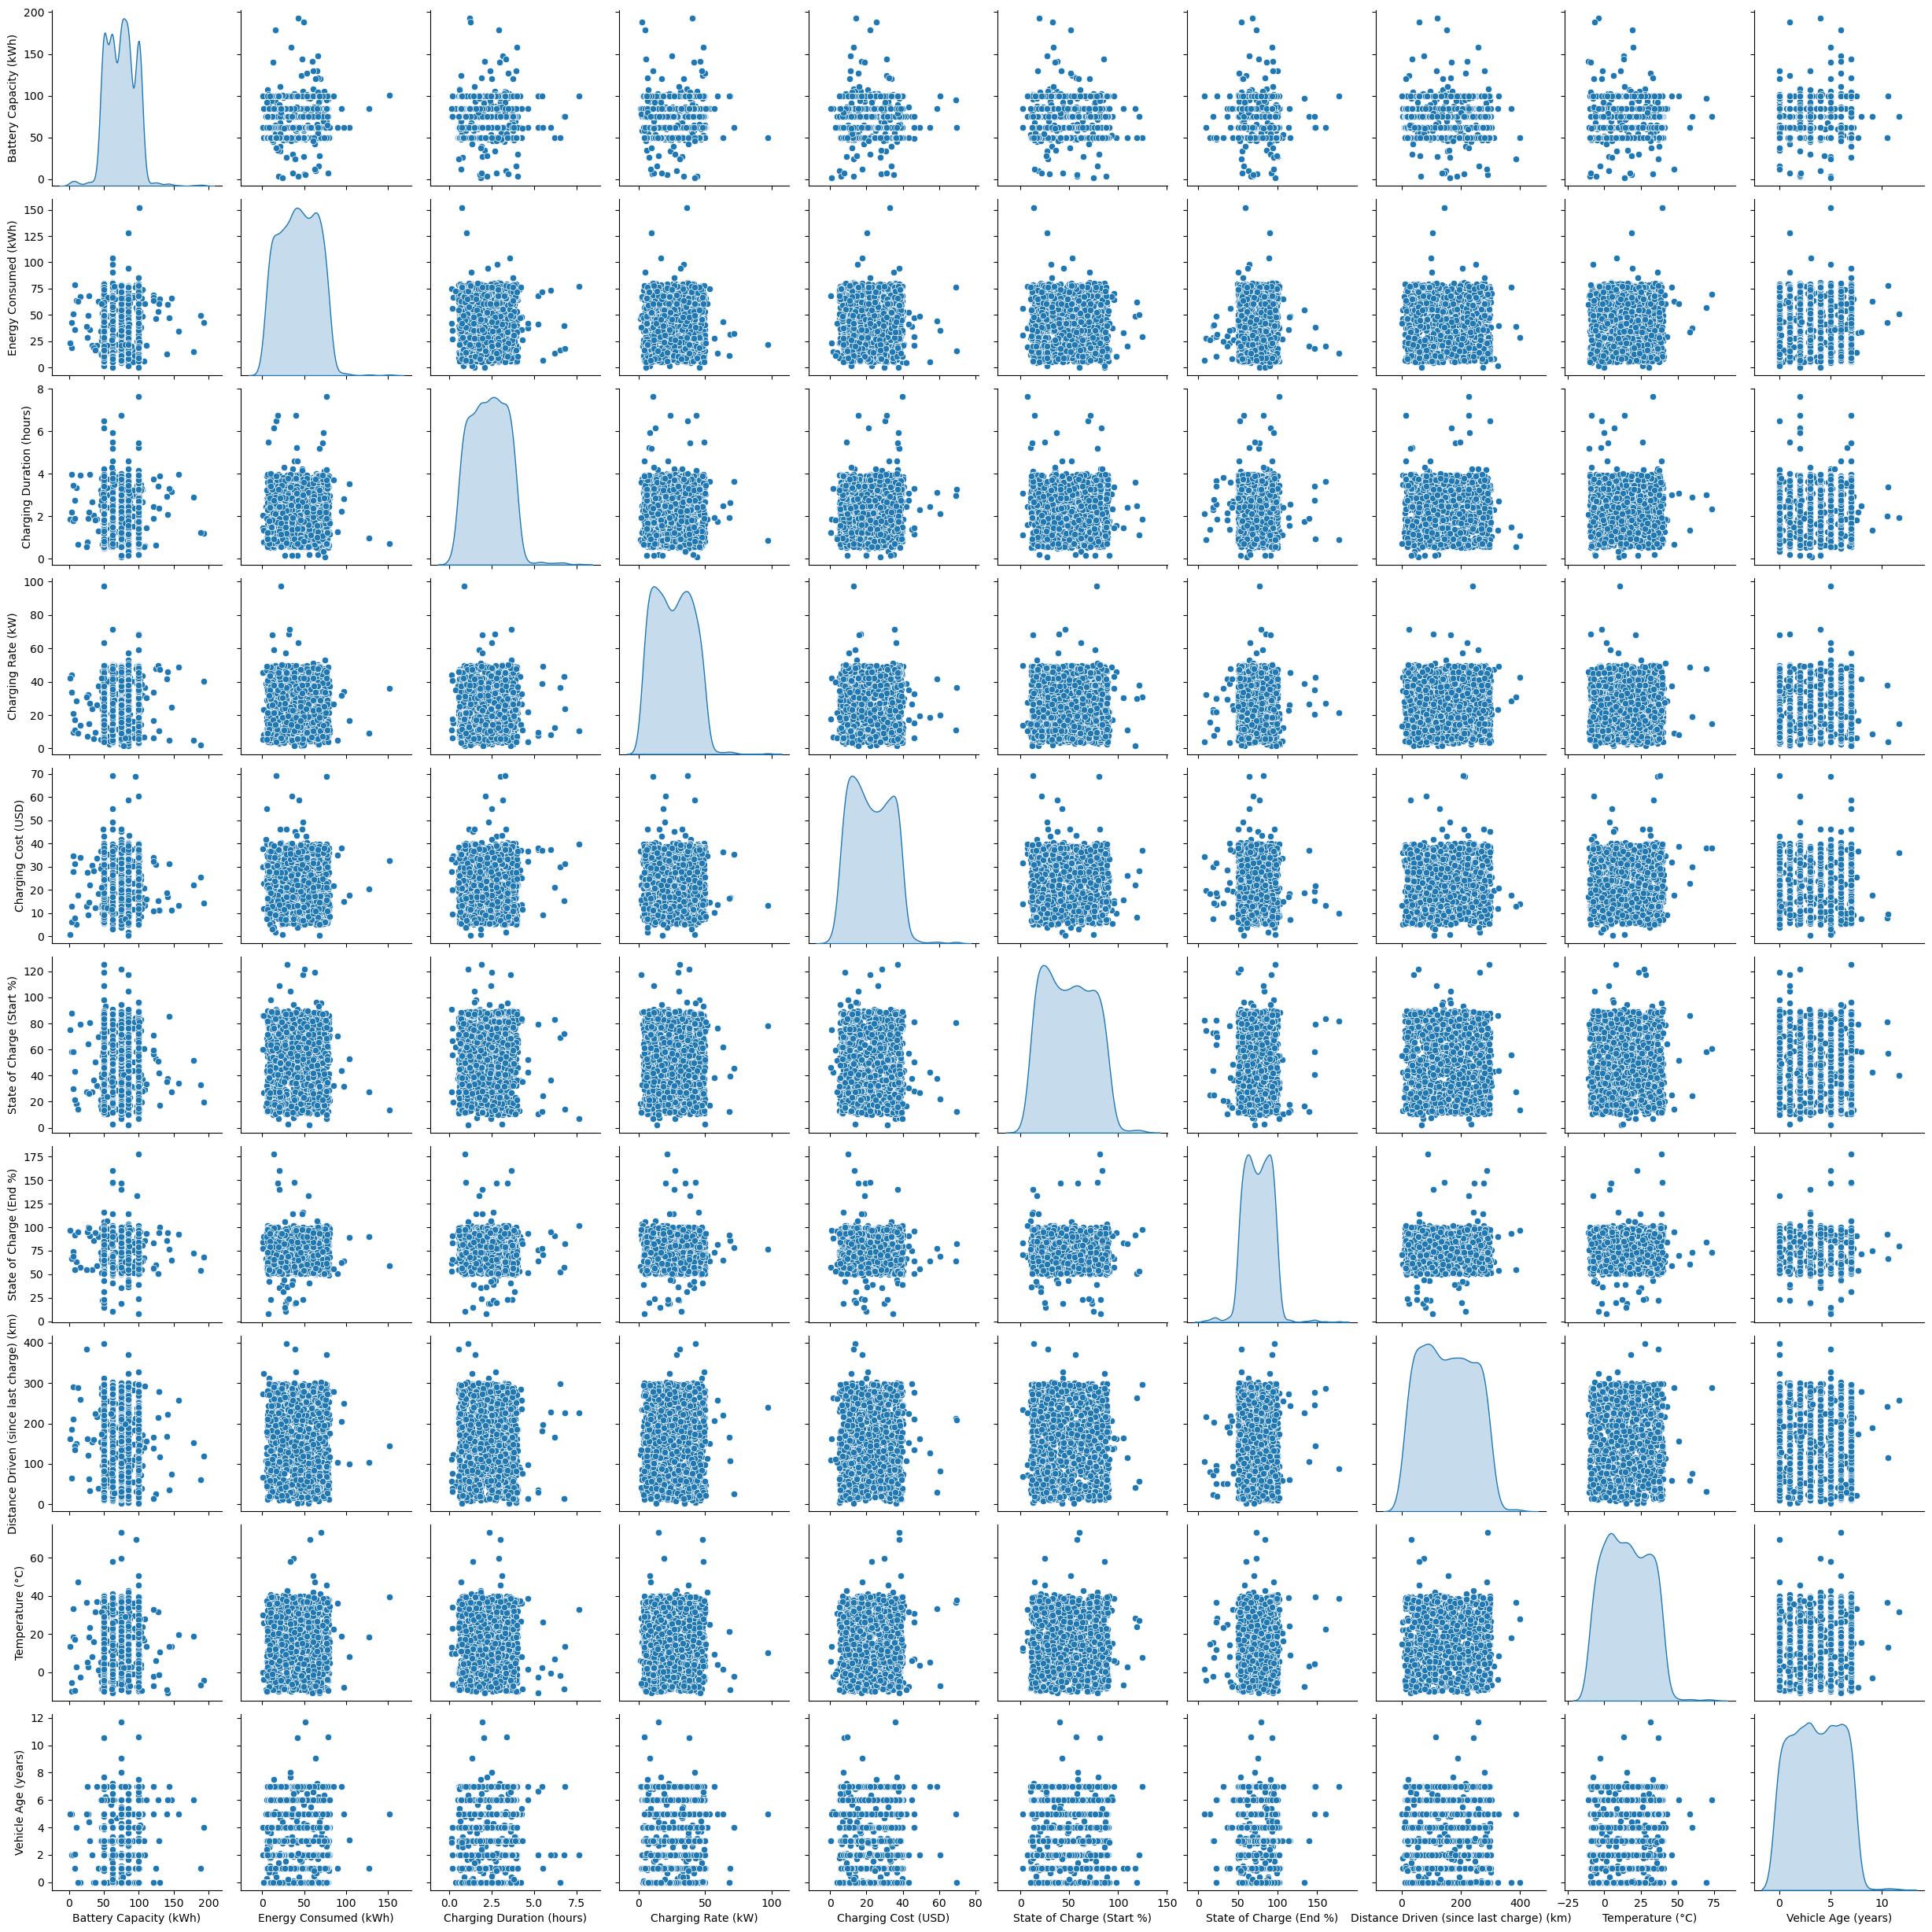

In [23]:
sns.pairplot(df, diag_kind = 'kde')

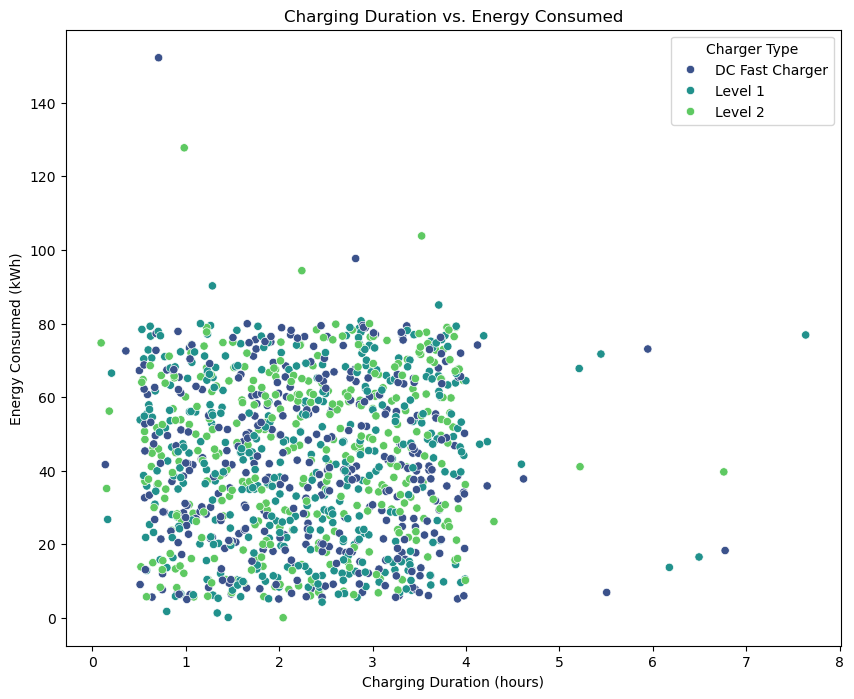

In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Charging Duration (hours)', y='Energy Consumed (kWh)', hue='Charger Type', palette='viridis')
plt.title('Charging Duration vs. Energy Consumed')
plt.xlabel('Charging Duration (hours)')
plt.ylabel('Energy Consumed (kWh)')
plt.show()

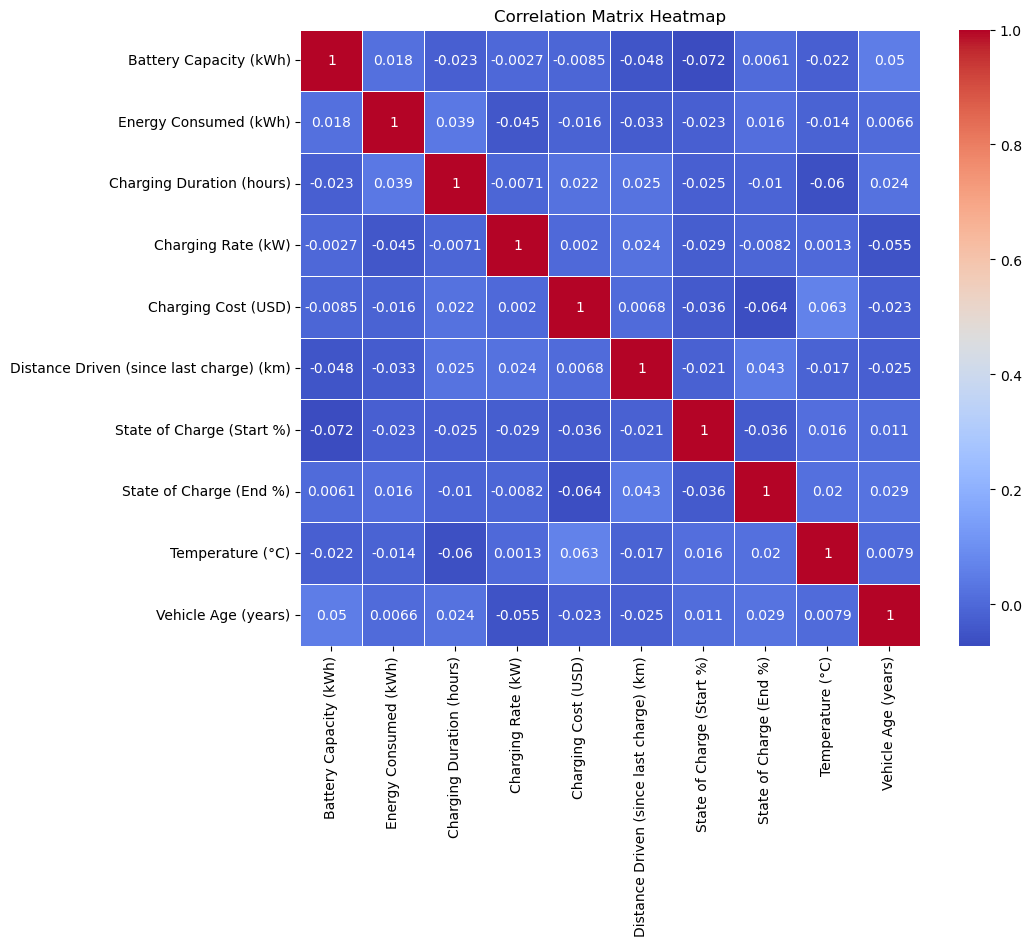

In [25]:
corr_columns = [
    'Battery Capacity (kWh)', 'Energy Consumed (kWh)', 'Charging Duration (hours)', 
    'Charging Rate (kW)', 'Charging Cost (USD)', 'Distance Driven (since last charge) (km)', 
    'State of Charge (Start %)', 'State of Charge (End %)', 'Temperature (°C)', 'Vehicle Age (years)'
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

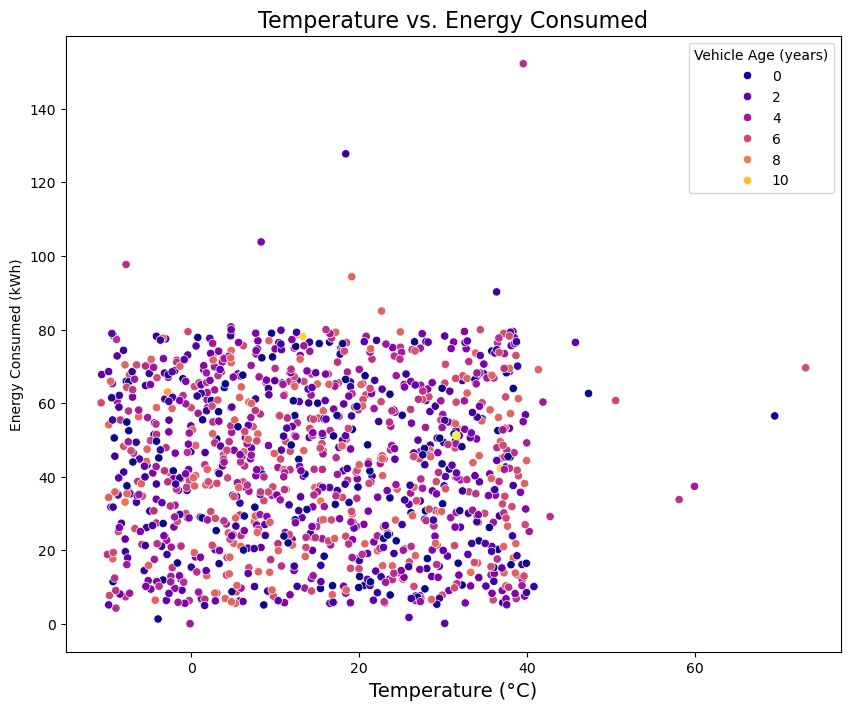

In [26]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Temperature (°C)', y='Energy Consumed (kWh)', hue='Vehicle Age (years)', palette='plasma')
plt.title('Temperature vs. Energy Consumed', fontsize = 16)
plt.xlabel('Temperature (°C)',fontsize = 14)
plt.ylabel('Energy Consumed (kWh)')
plt.show()

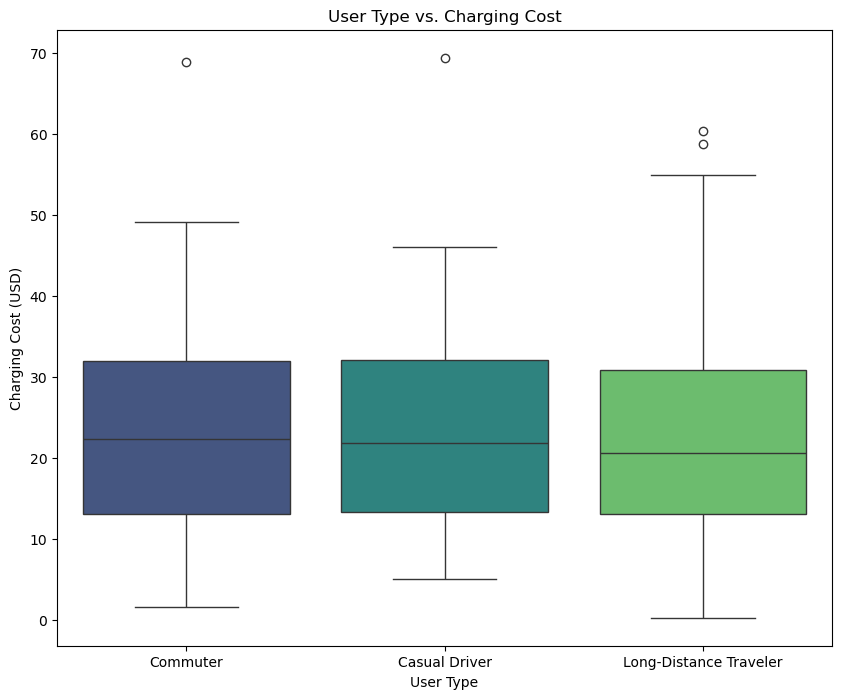

In [27]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='User Type', y='Charging Cost (USD)', palette='viridis')
plt.title('User Type vs. Charging Cost')
plt.xlabel('User Type')
plt.ylabel('Charging Cost (USD)')
plt.show()

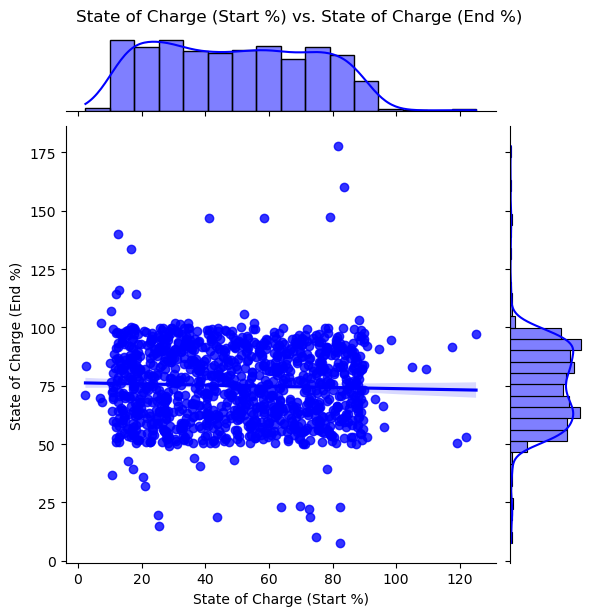

In [28]:
sns.jointplot(x='State of Charge (Start %)', y='State of Charge (End %)', data=df, kind='reg', color='blue')
plt.suptitle('State of Charge (Start %) vs. State of Charge (End %)', y=1.02)
plt.xlabel('State of Charge (Start %)')
plt.ylabel('State of Charge (End %)')
plt.show()

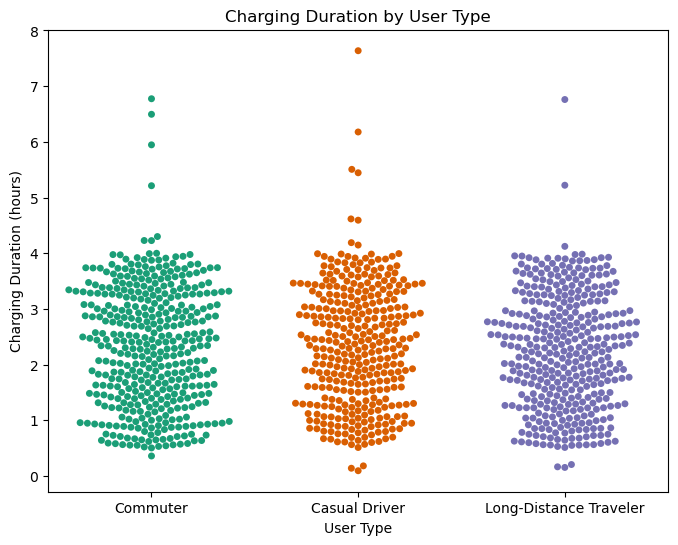

In [29]:
plt.figure(figsize=(8, 6))
sns.swarmplot(x='User Type', y='Charging Duration (hours)', data=df, palette='Dark2')
plt.title('Charging Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Charging Duration (hours)')
plt.show()

In [30]:
df.columns

Index(['User ID', 'Vehicle Model', 'Battery Capacity (kWh)',
       'Charging Station ID', 'Charging Station Location',
       'Charging Start Time', 'Charging End Time', 'Energy Consumed (kWh)',
       'Charging Duration (hours)', 'Charging Rate (kW)',
       'Charging Cost (USD)', 'Time of Day', 'Day of Week',
       'State of Charge (Start %)', 'State of Charge (End %)',
       'Distance Driven (since last charge) (km)', 'Temperature (°C)',
       'Vehicle Age (years)', 'Charger Type', 'User Type'],
      dtype='object')

<Figure size 1000x800 with 0 Axes>

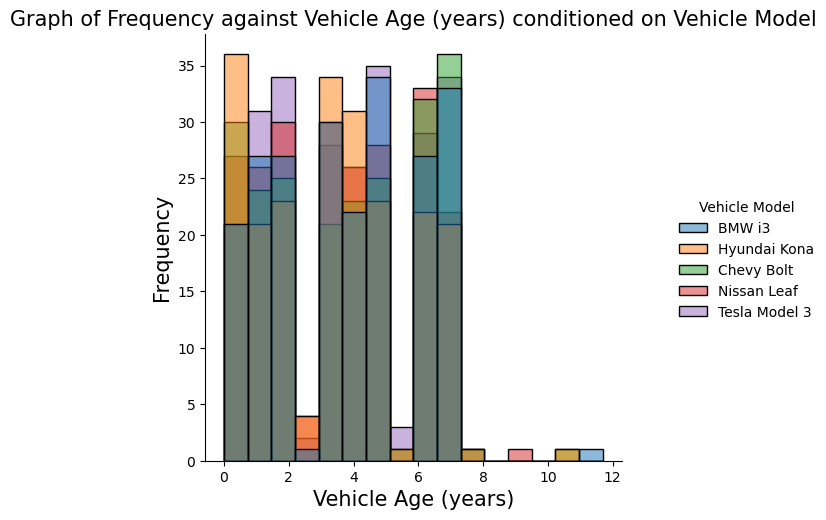

In [31]:
plt.figure(figsize = (10, 8))
sns.displot(df, x='Vehicle Age (years)', hue='Vehicle Model');
plt.xlabel("Vehicle Age (years)", fontsize = 15)
plt.ylabel("Frequency", fontsize = 15)
plt.title("Graph of Frequency against Vehicle Age (years) conditioned on Vehicle Model", fontsize = 15)
plt.savefig('VehicleAge_histogram.png');

In [32]:
df.dtypes

User ID                                      object
Vehicle Model                                object
Battery Capacity (kWh)                      float64
Charging Station ID                          object
Charging Station Location                    object
Charging Start Time                          object
Charging End Time                            object
Energy Consumed (kWh)                       float64
Charging Duration (hours)                   float64
Charging Rate (kW)                          float64
Charging Cost (USD)                         float64
Time of Day                                  object
Day of Week                                  object
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charger Type                                 object
User Type   

In [33]:
cat_df = df.select_dtypes(include=['object'])
cat_cols_lst = cat_df.columns
cat_cols_lst.tolist()

['User ID',
 'Vehicle Model',
 'Charging Station ID',
 'Charging Station Location',
 'Charging Start Time',
 'Charging End Time',
 'Time of Day',
 'Day of Week',
 'Charger Type',
 'User Type']

In [34]:
## numerical variables
num_data= df.select_dtypes(include=[np.number])
num_cols_lst = num_data.columns
num_cols_lst.tolist()

['Battery Capacity (kWh)',
 'Energy Consumed (kWh)',
 'Charging Duration (hours)',
 'Charging Rate (kW)',
 'Charging Cost (USD)',
 'State of Charge (Start %)',
 'State of Charge (End %)',
 'Distance Driven (since last charge) (km)',
 'Temperature (°C)',
 'Vehicle Age (years)']